# Penjelasan Cara Kerja GAN

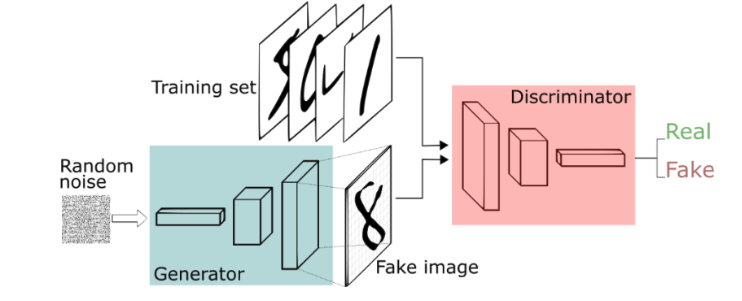

Diagram di atas menunjukkan proses Generative Adversarial Network (GAN). Arsitektur ini bekerja dengan cara menyuruh dua neural network untuk saling bersaing: Generator dan Discriminator.

* Generator: Neural network yang bertugas untuk membuat data baru yang terlihat semirip mungkin dengan data asli. Bisa dibilang bahwa generator ini adalah seorang seniman yang ditugaskan untuk meniru artwork asli semirip mungkin.
* Discriminator: Neural network yang bertugas untuk memeriksa data buatan genrator. Perannya adalah membedakan apakah gambar yang masuk kepadanya merupakan gambar asli dari dataset atau gambar palsu buatan Generator. Discriminator ini semacam kritikus expert yang ditugaskan untuk memilah artwork asli dan mana yang tiruan.

Secara umum, berikut proses kerjanya:

* Generator membuat gambar tiruan: Awalnya, Generator menerima input berupa Random Noise (vektor acak yang berisi angka-angka random), lalu lewat beberapa neural network, Generator belajar untuk mengubah noise acak tersebut menjadi sebuah struktur gambar. Outputnya adalah fake image dari proses ini.
* Discriminator menilai gambar asli dan tiruan: Discriminator akan menerima input dari dua sumber (bisa bergantian atau dicampur dalam satu batch), yaitu real image (dari training set) dan fake image (dari output generator). Real image adalah gambar original yang diambil dari training dataset, sedangkan fake image merupakan gambar tiruan oleh Generator. Discriminator akan memproses gambar yang masuk menggunakan neural networknya sendiri. Outputnya adalah sebuah probabilitas biner, yaitu Real (jika Discriminator yakin gambar tersebut berasal dari dataset asli / Real Image) dan Fake (jika Discriminator mendeteksi gambar itu adalah buatan Generator / Fake Image).
* Generator dan Discriminator terus-menerus bersaing: Proses latihan akan dilakukan berulang-ulang. Generator dilatih untuk meminimalkan peluang Discriminator mengenali kesalahannya. Dengan kata lain, Generator terus memperbaiki diri agar bisa "menipu" Discriminator sehingga gambar palsunya dikira Real. Di sisi lain, Discriminator dilatih untuk semakin teliti. Ia terus memperbaiki kemampuannya agar tidak mudah tertipu oleh Generator dan bisa mendeteksi mana yang Fake dengan tepat. Seiring berjalannya waktu proses training, Generator akan menjadi sangat mahir dalam membuat gambar yang sangat realistis, hingga pada akhirnya Discriminator kesulitan membedakan mana gambar yang asli dan mana yang palsu (tingkat akurasi tebakan mendekati 50%).


# GAN Baseline Architecture

## Data Loading

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms.functional as TF
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

!pip install -q torchmetrics[image]
from torchmetrics.image.fid import FrechetInceptionDistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TARGET_CLASSES = ["oil_gas_field", "stadium"]
TRAIN_DIR = "/kaggle/input/datasets/datamunge/overheadmnist/overhead/training"
TEST_DIR = "/kaggle/input/datasets/datamunge/overheadmnist/overhead/testing"

IMG_SIZE = 28
N_LABELS = len(TARGET_CLASSES)
NOISE_DIM = 100
BATCH_SIZE = 64
NUM_EPOCHS = 301

LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999

print(f"Device : {device}")
print(f"Classes: {TARGET_CLASSES}  (N_LABELS={N_LABELS})")

Device : cuda
Classes: ['oil_gas_field', 'stadium']  (N_LABELS=2)


In [3]:
#function utk ambil cuma oil_gas_field dan stadium
class FilteredImageFolder(datasets.ImageFolder):
    def __init__(self, root, target_classes, transform=None):
        self.target_classes      = target_classes
        self.normalized_targets  = [c.replace("_", "-") for c in target_classes]
        super().__init__(root, transform=transform)

        filtered = []
        for path, idx in self.samples:
            cls = self.classes[idx]
            if cls in self.target_classes:
                filtered.append((path, self.target_classes.index(cls)))
            elif cls in self.normalized_targets:
                filtered.append((path, self.normalized_targets.index(cls)))

        self.samples = filtered
        self.targets = [s[1] for s in filtered]

    def _find_classes(self, directory):
        all_cls = [d.name for d in os.scandir(directory) if d.is_dir()]
        active  = [c for c in all_cls
                   if c in self.target_classes or c in self.normalized_targets]
        cls_to_idx = {c: i for i, c in enumerate(active)}
        return active, cls_to_idx

In [4]:
#loading train dataset
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = FilteredImageFolder(
    root=TRAIN_DIR, target_classes=TARGET_CLASSES, transform=transform_train
)
dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

print(f"Train images : {len(train_dataset)}")
print(f"Batches: {len(dataloader)}")

Train images : 1731
Batches: 27


In [5]:
#loading testing dataset
transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # ← ditambahkan, sebelumnya tidak ada
])

test_dataset = FilteredImageFolder(
    root=TEST_DIR, target_classes=TARGET_CLASSES, transform=transform_test
)
val_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test images: {len(test_dataset)}")
print(f"Label map: {TARGET_CLASSES} = [0, 1]")

Test images: 215
Label map: ['oil_gas_field', 'stadium'] = [0, 1]


In [6]:
def preprocess_for_fid(imgs: torch.Tensor) -> torch.Tensor:
    imgs = (imgs + 1) / 2
    imgs = imgs.clamp(0, 1)
    if imgs.size(1) == 1:
        imgs = imgs.repeat(1, 3, 1, 1)
    imgs = torch.nn.functional.interpolate(
        imgs, size=(299, 299), mode='bilinear', align_corners=False
    )
    imgs = (imgs * 255).to(torch.uint8)
    return imgs

## Generator Model

In [7]:
class GeneratorBaseline(nn.Module):
    def __init__(self, noise_dim: int, n_labels: int, img_size: int):
        super().__init__()
        self.img_size  = img_size
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.model = nn.Sequential(
            nn.Linear(noise_dim + n_labels, 128),
            nn.Linear(128, 256),
            nn.Linear(256, 512),
            nn.Linear(512, 1024),
            nn.Linear(1024, img_size * img_size)
        )

    def forward(self, z: torch.Tensor, labels: torch.LongTensor) -> torch.Tensor:
        label_emb = self.label_emb(labels)           # (B, n_labels)
        x         = torch.cat([z, label_emb], dim=1) # (B, noise_dim + n_labels)
        img_flat  = self.model(x)                    # (B, img_size^2)
        return img_flat.view(-1, 1, self.img_size, self.img_size)

GeneratorBaseline

__main__.GeneratorBaseline

## Discriminator Model

In [8]:
class DiscriminatorBaseline(nn.Module):
    def __init__(self, n_labels: int, img_size: int):
        super().__init__()
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.model = nn.Sequential(
            nn.Linear(n_labels + img_size * img_size, 512),
            nn.Linear(512, 1024),
            nn.Linear(1024, 1024),
            nn.Linear(1024, 512),
            nn.Linear(512, 1)
        )

    def forward(self, img: torch.Tensor, labels: torch.LongTensor) -> torch.Tensor:
        label_emb = self.label_emb(labels) # (B, n_labels)
        img_flat  = img.view(img.size(0), -1) # (B, img_size^2)
        x         = torch.cat([img_flat, label_emb], dim=1)  # (B, n_labels + img_size^2)
        return self.model(x)

DiscriminatorBaseline

__main__.DiscriminatorBaseline

In [9]:
gen_b  = GeneratorBaseline(NOISE_DIM, N_LABELS, IMG_SIZE).to(device)
disc_b = DiscriminatorBaseline(N_LABELS, IMG_SIZE).to(device)

print(gen_b)
print(disc_b)

GeneratorBaseline(
  (label_emb): Embedding(2, 2)
  (model): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): Linear(in_features=1024, out_features=784, bias=True)
  )
)
DiscriminatorBaseline(
  (label_emb): Embedding(2, 2)
  (model): Sequential(
    (0): Linear(in_features=786, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=1024, bias=True)
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): Linear(in_features=512, out_features=1, bias=True)
  )
)


## Training Process

In [10]:
criterion   = nn.BCEWithLogitsLoss()
opt_g_b     = optim.Adam(gen_b.parameters(),  lr=LR, betas=(BETA1, BETA2))
opt_d_b     = optim.Adam(disc_b.parameters(), lr=LR, betas=(BETA1, BETA2))

[Baseline] Epoch 0/301 | Loss D: 1.3709 | Loss G: 0.7602


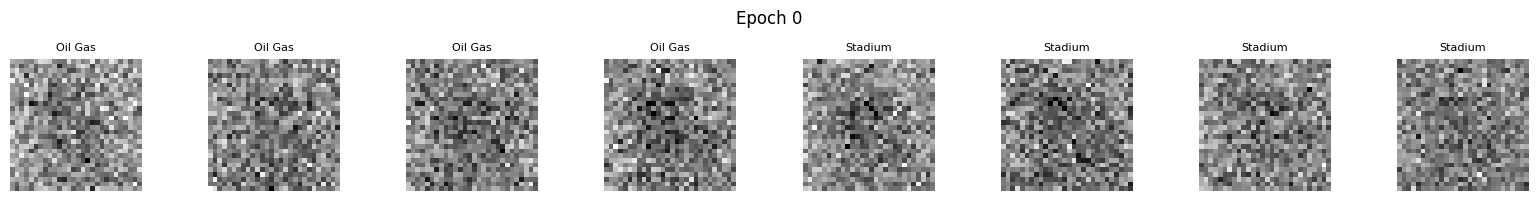

[Baseline] Epoch 10/301 | Loss D: 1.3849 | Loss G: 0.6991


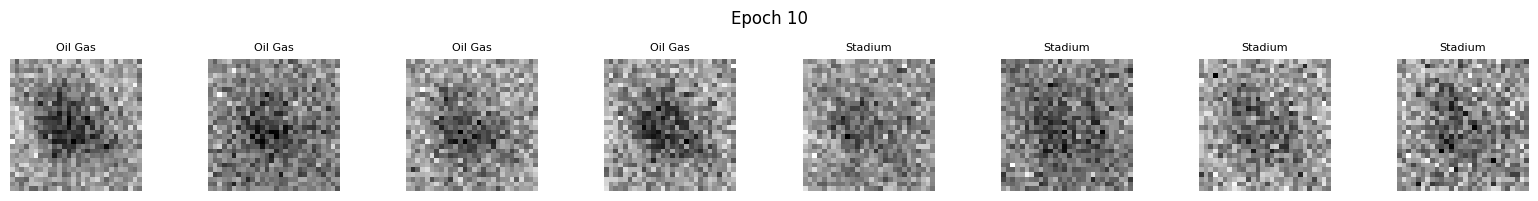

[Baseline] Epoch 20/301 | Loss D: 1.3899 | Loss G: 0.6898


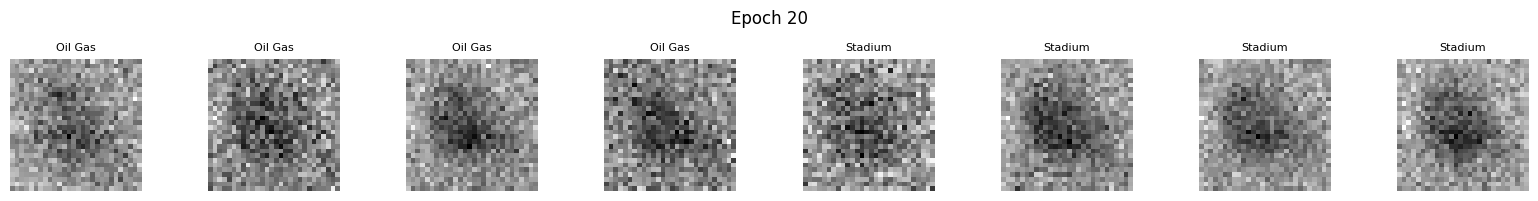

[Baseline] Epoch 30/301 | Loss D: 1.3904 | Loss G: 0.6906


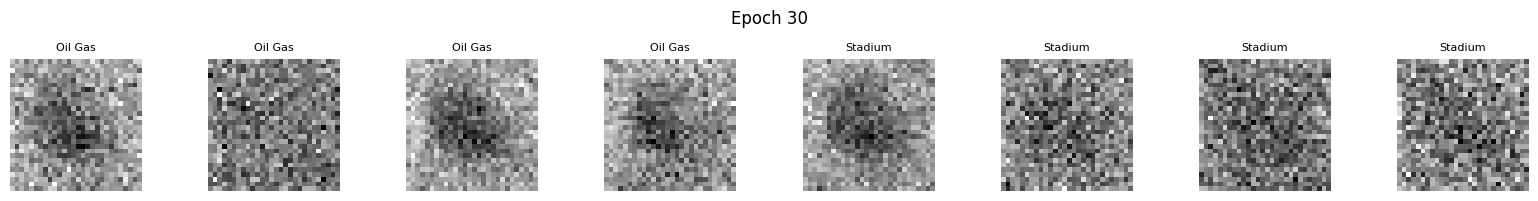

[Baseline] Epoch 40/301 | Loss D: 1.3905 | Loss G: 0.6916


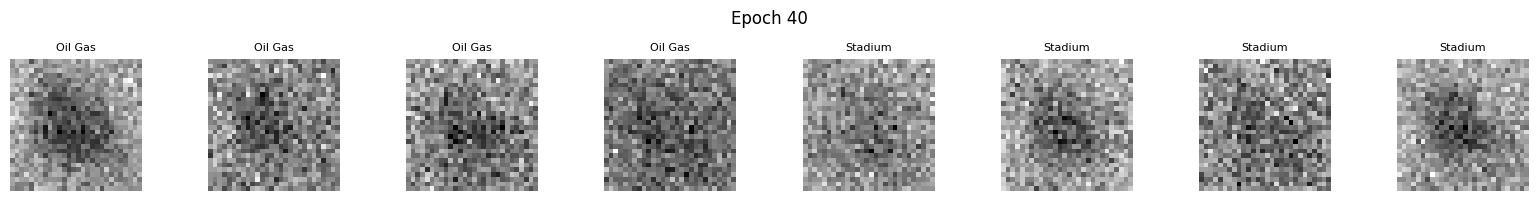

[Baseline] Epoch 50/301 | Loss D: 1.3855 | Loss G: 0.6922


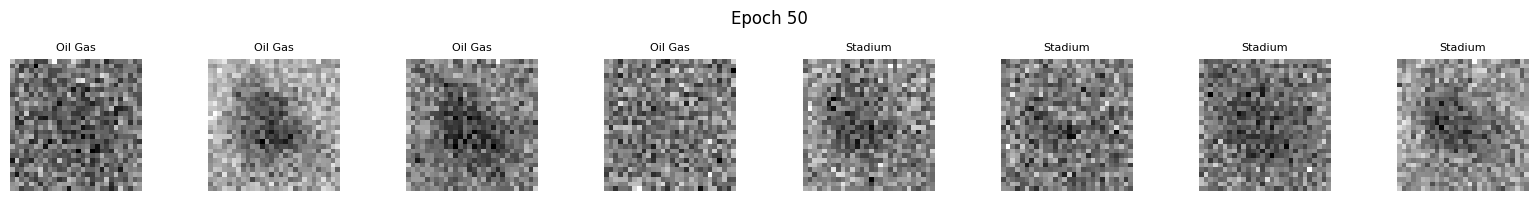

[Baseline] Epoch 60/301 | Loss D: 1.3925 | Loss G: 0.6901


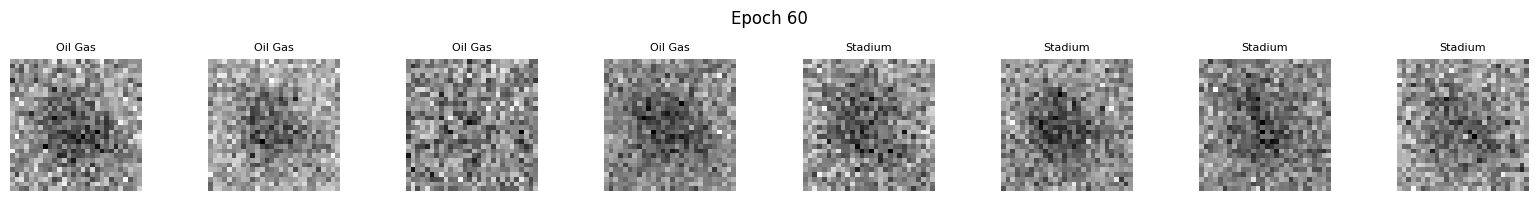

[Baseline] Epoch 70/301 | Loss D: 1.3852 | Loss G: 0.6978


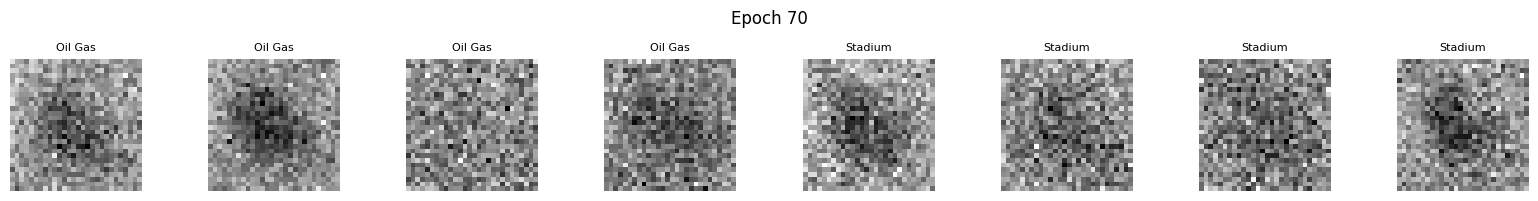

[Baseline] Epoch 80/301 | Loss D: 1.3843 | Loss G: 0.6917


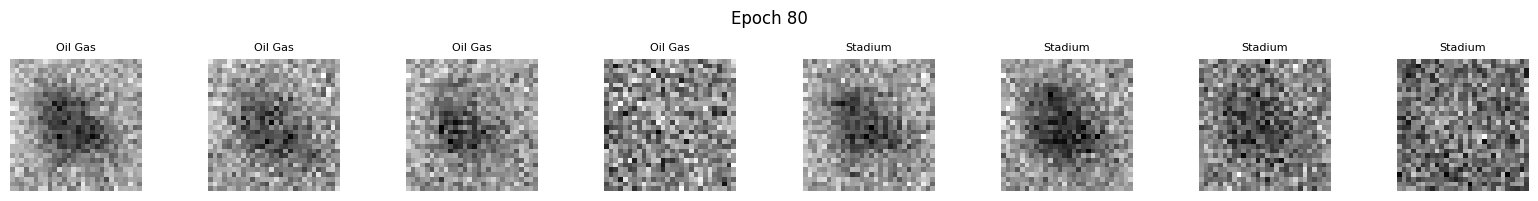

[Baseline] Epoch 90/301 | Loss D: 1.3898 | Loss G: 0.6906


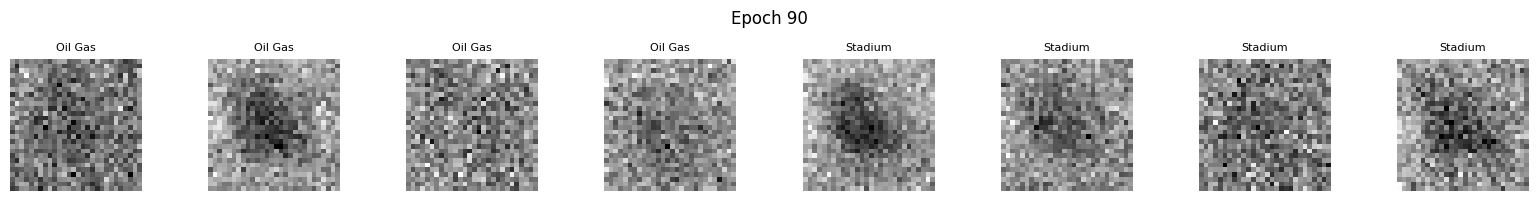

[Baseline] Epoch 100/301 | Loss D: 1.3870 | Loss G: 0.6920


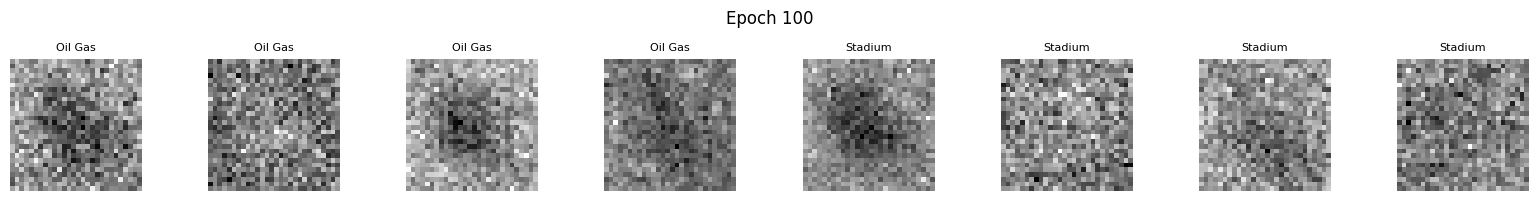

[Baseline] Epoch 110/301 | Loss D: 1.3826 | Loss G: 0.6970


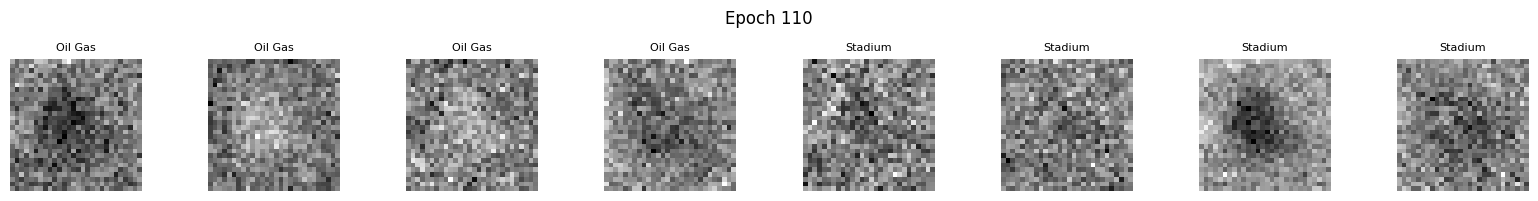

[Baseline] Epoch 120/301 | Loss D: 1.3896 | Loss G: 0.6872


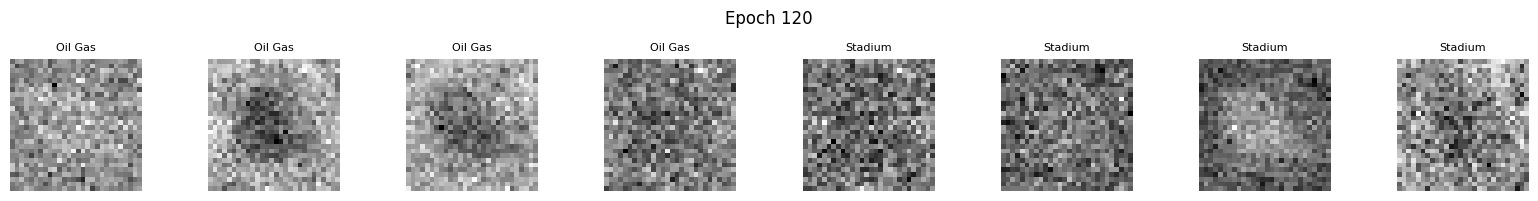

[Baseline] Epoch 130/301 | Loss D: 1.3865 | Loss G: 0.6962


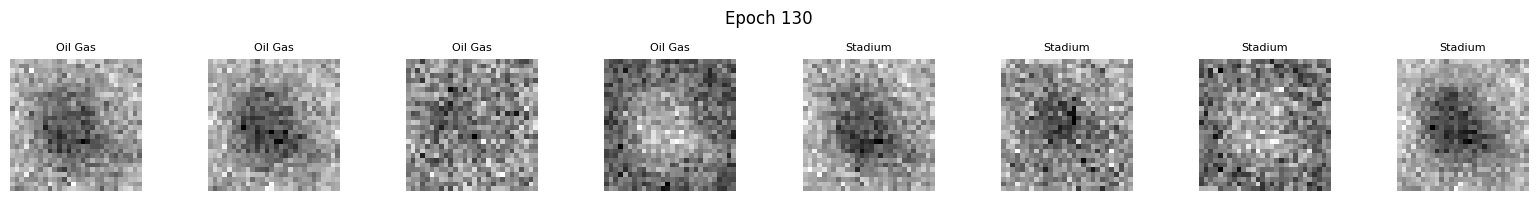

[Baseline] Epoch 140/301 | Loss D: 1.3856 | Loss G: 0.6960


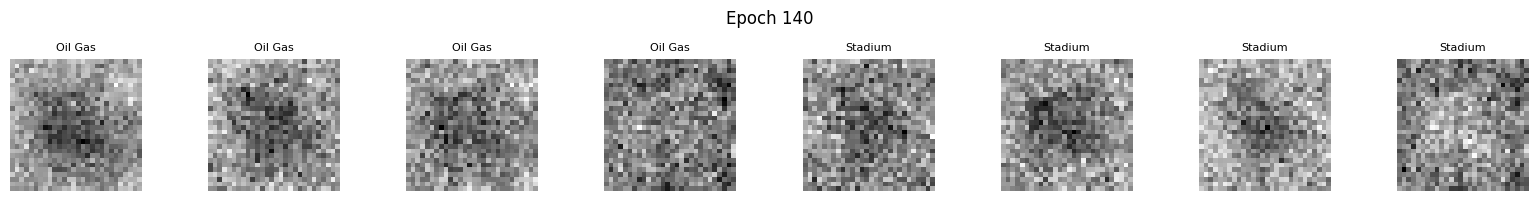

[Baseline] Epoch 150/301 | Loss D: 1.3875 | Loss G: 0.6958


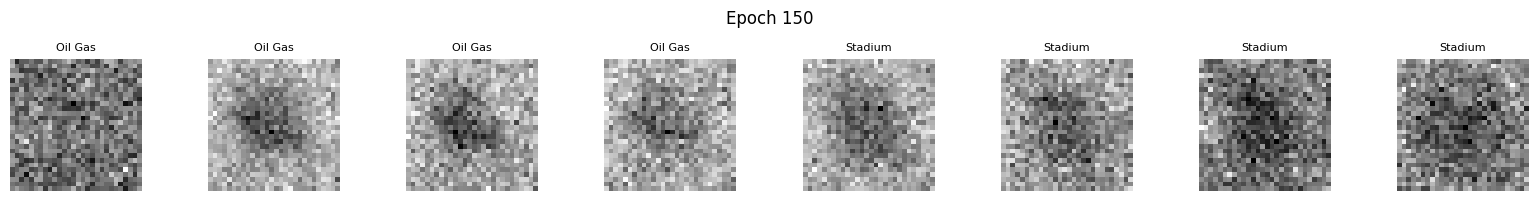

[Baseline] Epoch 160/301 | Loss D: 1.3809 | Loss G: 0.6966


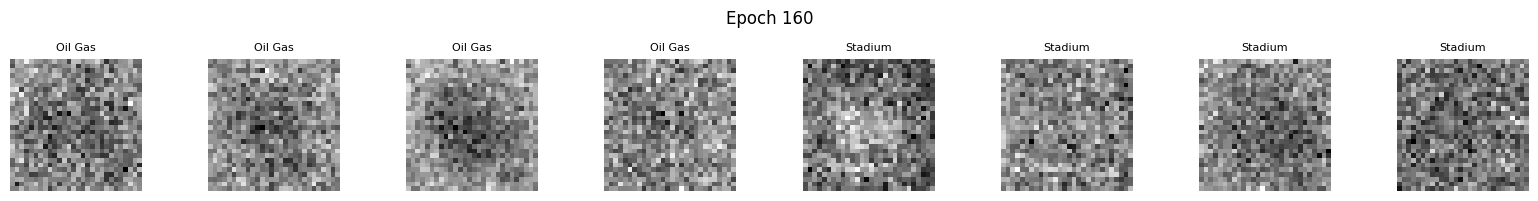

[Baseline] Epoch 170/301 | Loss D: 1.3858 | Loss G: 0.6932


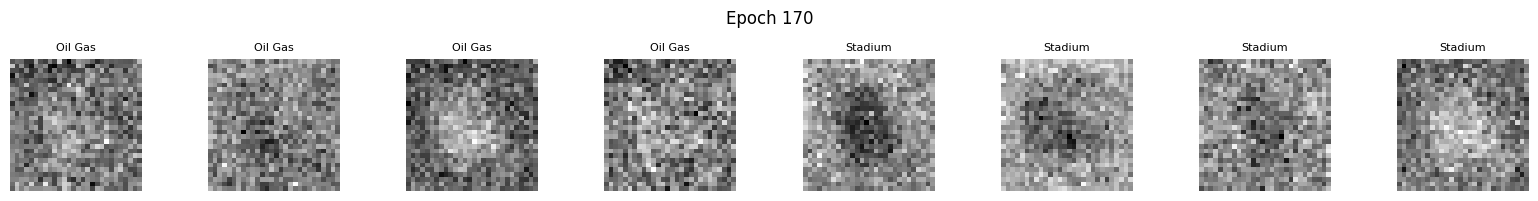

[Baseline] Epoch 180/301 | Loss D: 1.3855 | Loss G: 0.6932


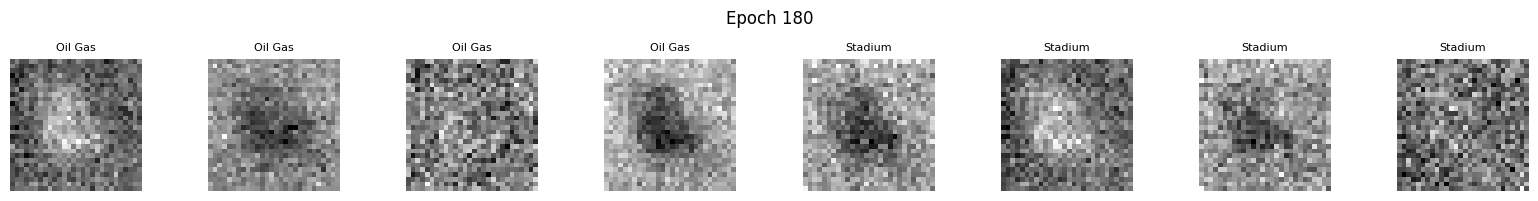

[Baseline] Epoch 190/301 | Loss D: 1.3867 | Loss G: 0.6930


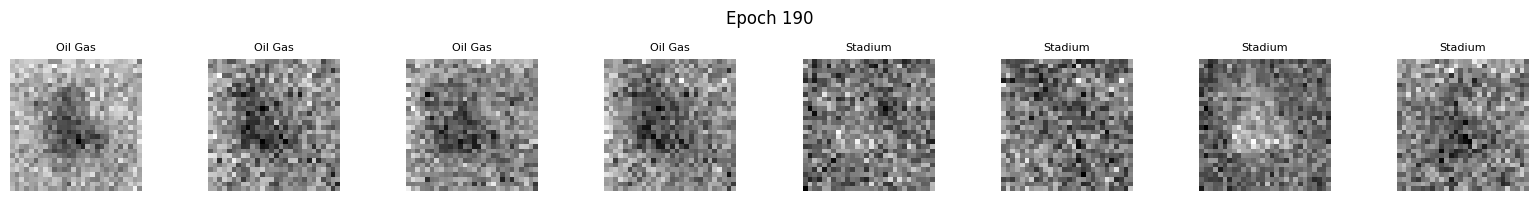

[Baseline] Epoch 200/301 | Loss D: 1.3861 | Loss G: 0.6936


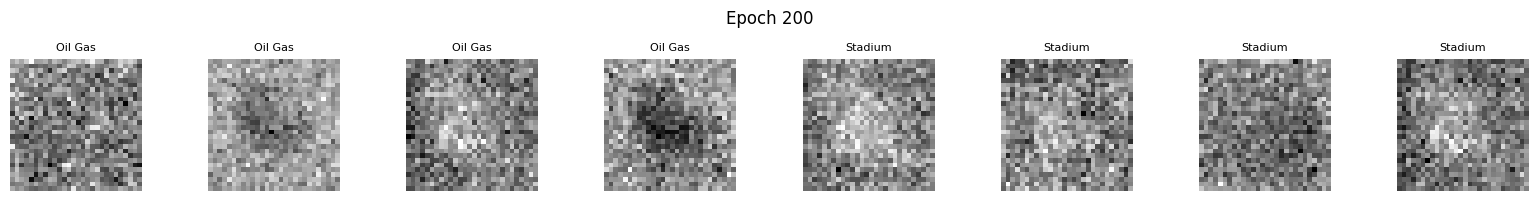

[Baseline] Epoch 210/301 | Loss D: 1.3863 | Loss G: 0.6930


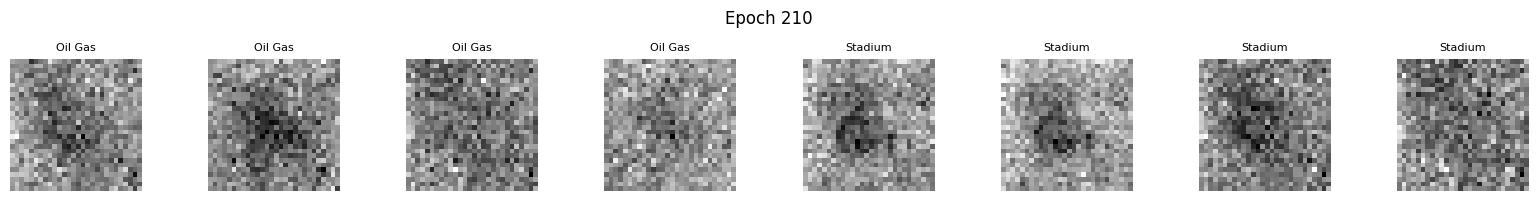

[Baseline] Epoch 220/301 | Loss D: 1.3862 | Loss G: 0.6945


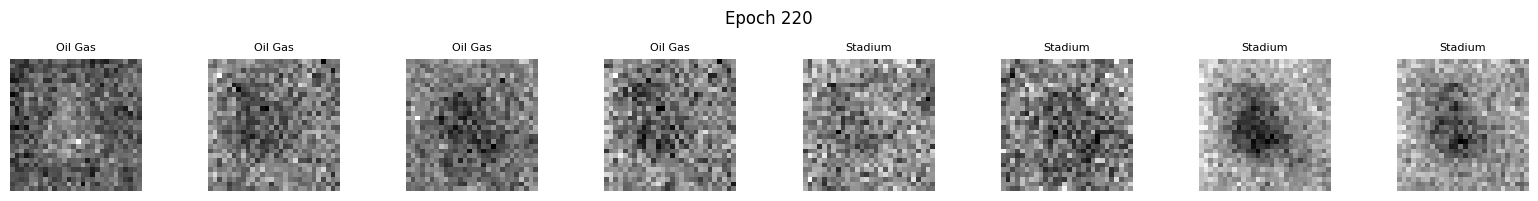

[Baseline] Epoch 230/301 | Loss D: 1.4037 | Loss G: 0.6890


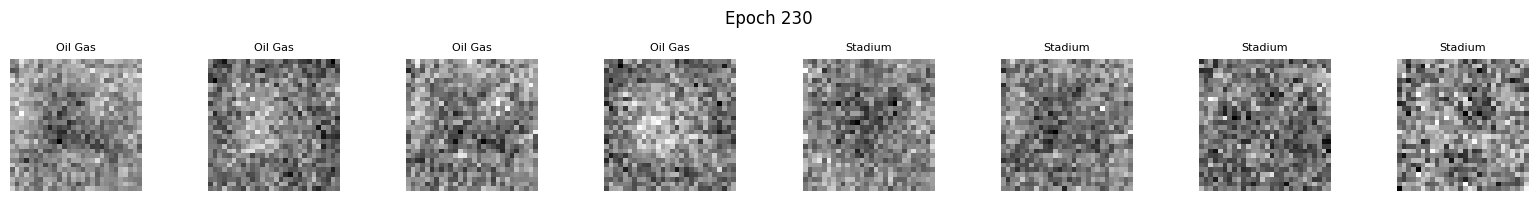

[Baseline] Epoch 240/301 | Loss D: 1.3871 | Loss G: 0.6932


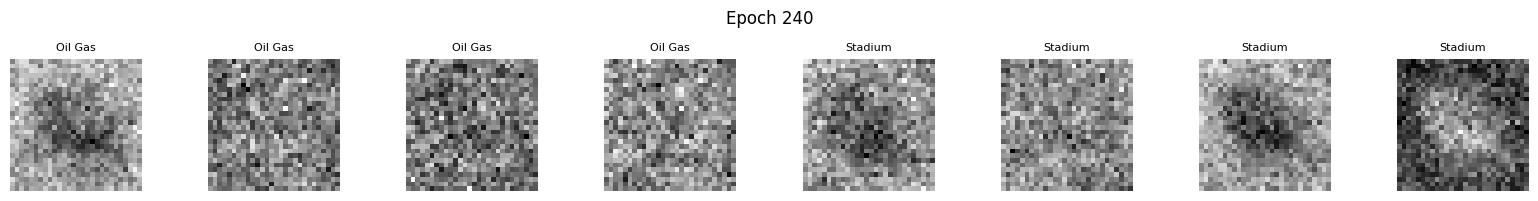

[Baseline] Epoch 250/301 | Loss D: 1.3860 | Loss G: 0.6948


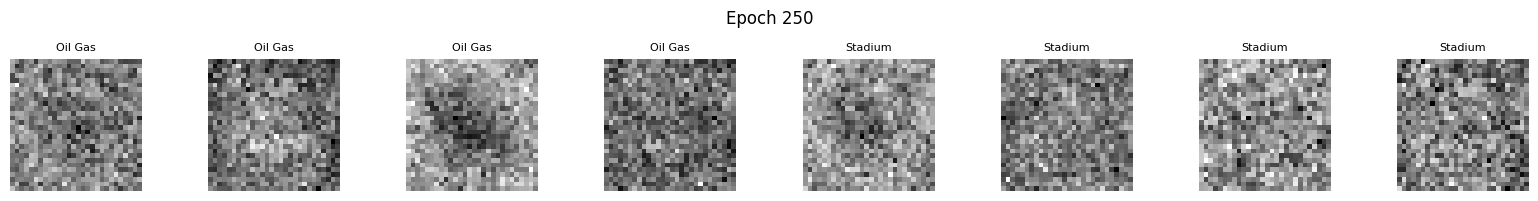

[Baseline] Epoch 260/301 | Loss D: 1.3864 | Loss G: 0.6929


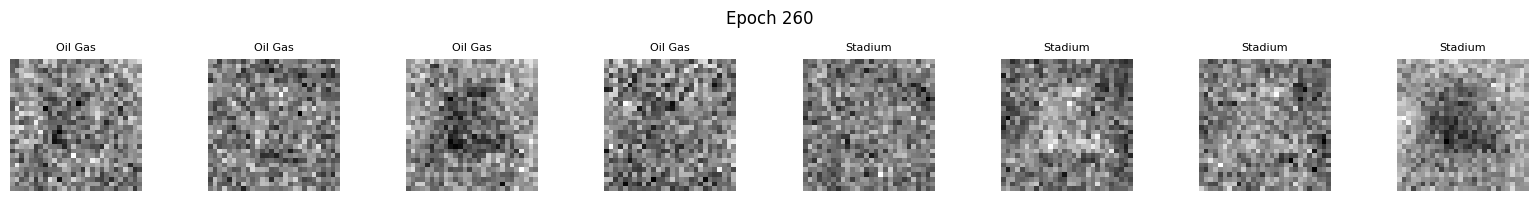

[Baseline] Epoch 270/301 | Loss D: 1.3864 | Loss G: 0.6933


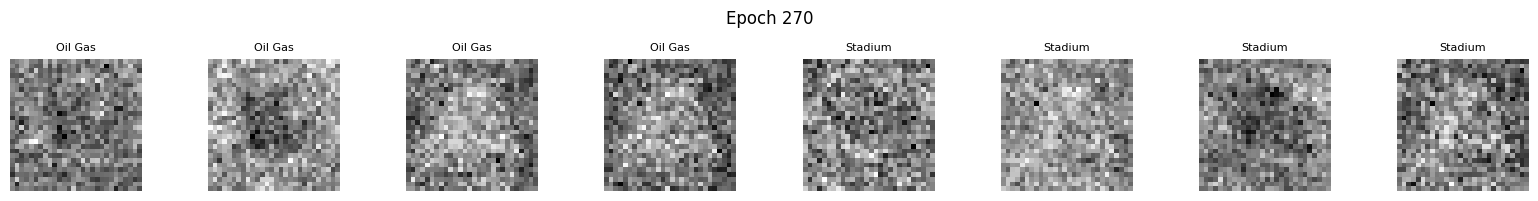

[Baseline] Epoch 280/301 | Loss D: 1.3863 | Loss G: 0.6933


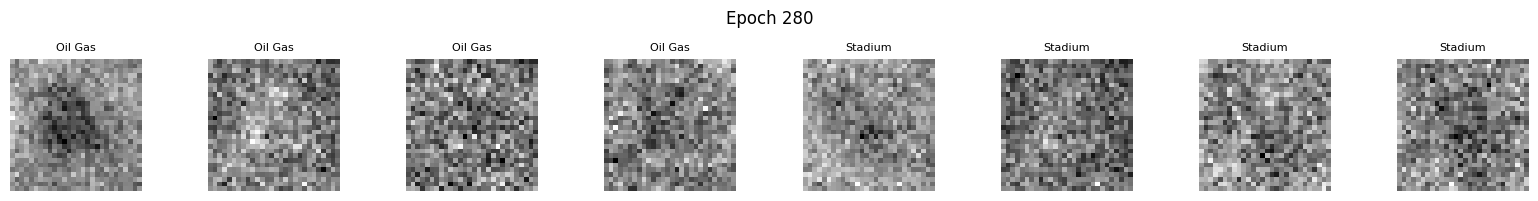

[Baseline] Epoch 290/301 | Loss D: 1.3863 | Loss G: 0.6931


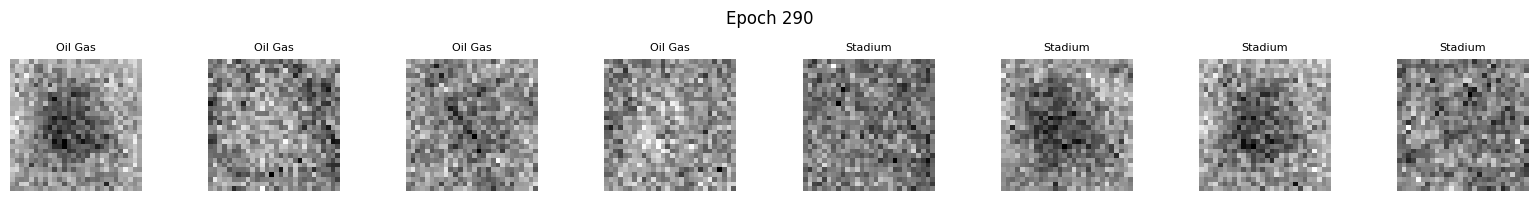

[Baseline] Epoch 300/301 | Loss D: 1.3857 | Loss G: 0.6944


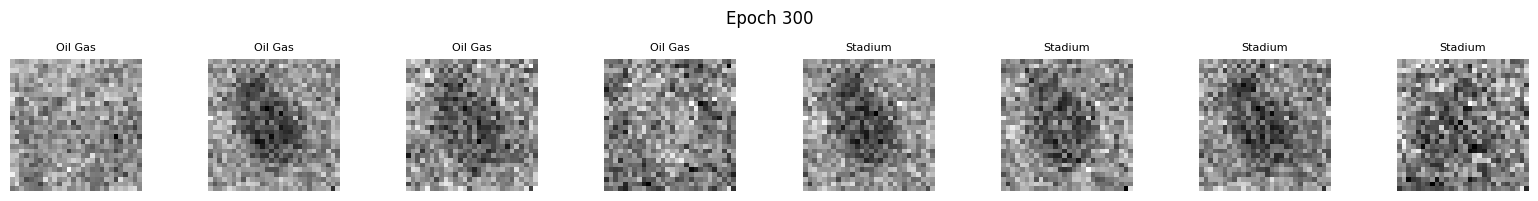

In [11]:
#trainig baseline
for epoch in range(NUM_EPOCHS + 1):
    gen_b.train()
    disc_b.train()

    for real_imgs, labels in dataloader:
        B = real_imgs.size(0)

        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)

        real_tgt  = torch.ones(B, 1, device=device)
        fake_tgt  = torch.zeros(B, 1, device=device)

        # Discriminator
        disc_b.zero_grad()

        out_real  = disc_b(real_imgs, labels)
        loss_real = criterion(out_real, real_tgt)

        z          = torch.randn(B, NOISE_DIM, device=device)
        fake_imgs  = gen_b(z, labels)
        out_fake   = disc_b(fake_imgs.detach(), labels)
        loss_fake  = criterion(out_fake, fake_tgt)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d_b.step()

        # Generator
        gen_b.zero_grad()

        z         = torch.randn(B, NOISE_DIM, device=device)
        fake_imgs = gen_b(z, labels)
        out       = disc_b(fake_imgs, labels)

        loss_g = criterion(out, real_tgt)
        loss_g.backward()
        opt_g_b.step()

    # Display epoch sample
    if epoch % 10 == 0:
        print(f"[Baseline] Epoch {epoch}/{NUM_EPOCHS} | "
              f"Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

        gen_b.eval()
        with torch.no_grad():
            vis_labels = torch.cat([torch.zeros(4), torch.ones(4)]).long().to(device)
            z_vis      = torch.randn(8, NOISE_DIM, device=device)
            imgs_vis   = gen_b(z_vis, vis_labels).cpu()
            imgs_vis   = (imgs_vis+1)/2

        fig, axes = plt.subplots(1, 8, figsize=(16, 2))
        for i in range(8):
            axes[i].imshow(imgs_vis[i].squeeze(), cmap="gray")
            axes[i].set_title("Oil Gas" if vis_labels[i] == 0 else "Stadium", fontsize=8)
            axes[i].axis("off")
        plt.suptitle(f"Epoch {epoch}")
        plt.tight_layout()
        plt.show()
        gen_b.train()

Melihat dari perubahan loss seiring epoch training bertambah, terlihat Loss D hanya di sekitar 1.1-1.3an dan Loss G di sekitar 0.6-0.8an. Hal ini menandakan model belum konvergensi sepenuhnya, karena terlihat bahwa model terjebak dengan kualitas output yang buruk. Kedua nilai tersebut kurang lebih sama dengan 2*ln(2) dan ln(2), yang merupakan nilai Binary Cross-Entropy ketika Discriminator secara konsisten mengeluarkan probabilitas 0,5 untuk setiap input. Artinya, Discriminator hanya menebak secara acak antara gambar asli dan palsu. Kondisi ini terjadi karena tanpa fungsi aktivasi non-linear, baik Generator maupun Discriminator tidak bisa mempelajari fitur yang bermakna. Alhasil, keduanya gagal belajar dan training stagnan sejak awal.

## FID Evaluation

In [12]:
#Hitung FID
gen_b.eval()
fid_b = FrechetInceptionDistance(feature=2048).to(device)

with torch.no_grad():
    for real_imgs, labels in val_loader:
        B         = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)

        z         = torch.randn(B, NOISE_DIM, device=device)
        fake_imgs = gen_b(z, labels)

        real_fid = preprocess_for_fid(real_imgs)
        fake_fid = preprocess_for_fid(fake_imgs)

        fid_b.update(real_fid, real=True)
        fid_b.update(fake_fid, real=False)

fid_score_baseline = fid_b.compute().item()
print(f"FID Score (Test Set): {fid_score_baseline:.4f}")

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 234MB/s]


FID Score (Test Set): 310.7437


Skor FID pada baseline model dengan test set hanya berada di 310.74. Hal ini berarti kualitas gambar sangat buruk karena gambar yang dihasilkan Generator sangat jauh dari distribusi gambar asli. Melihatnya secara visual, gambar  yang dihasilkan setiap 10 epoch masih berupa noise acak tanpa struktur objek yang mudah terlihat, baik untuk kelas oil gas field maupun stadium. Meskipun sudah mencapai 300 epoch, gambar yang diproduksi hanya seperti bayangan saja. Penyebab utama skor ini kemungkinan besar berasal dari tidak digunakannya fungsi aktivasi non-linear di antara setiap layer Linear pada Generator maupun Discriminator. Tanpa fungsi aktivasi, layer Linear yang ditumpuk hanya sama dengan satu transformasi linear tunggal. Akibatnya, model tidak memiliki kapasitas untuk mempelajari distribusi data gambar yang kompleks dan non-linear. Alhasil, Generator tidak berhasil mengubah noise input menjadi gambar yang jelas. Discriminator juga tidak bisa memberikan informasi lebih untuk melatih Generator secara efektif.

# GAN Modified Architecture

Berdasarkan hasil evaluasi baseline model, permasalahan utama yang harus di-handle adalah kegagalan Discriminator dan Generator dalam belajar akibat tidak adanya fungsi aktivasi non-linear di antara setiap layer. Oleh karena itu, modified arsitektur pada tahap ini berfokus pada perubahan sebagai berikut: 

Generator
* +) Penggunaan activation function Leaky ReLU, untuk mempertahankan gradien kecil nilai negatif sehingga bisa mencegah dying ReLU problem 
* +) BatchNorm1d setelah setiap Linear (kecuali output), mempercepat konvergensi dan menstabilkan distribusi fitur antar layer.
* +) Layer pertama diperbesar (128 → 256) agar latent space bisa direpresentasikan lebih baik sebelum diupscale.

Discriminator:
* +) Penggunaan activation function Leaky ReLU, untuk mempertahankan gradien kecil nilai negatif sehingga bisa mencegah dying ReLU problem
* +) Dropout(0.3) setelah setiap aktivasi, melemahkan dominasi D dan mencegah D converge terlalu cepat dibanding G.
* +) Pakai Gradient Penalty

Optimizer:
* +) Wasserstein loss + Gradient Penalty (WGAN-GP), loss lebih stabil, gradien tidak vanish, dan memberikan metric yang bermakna.
* +) n_critic=5, D dilatih 5x per update G agar W-distance akurat.
* +) Learning rate diturunkan ke 0.0001.

## Generator Model

In [13]:
class GeneratorModified(nn.Module):
    def __init__(self, noise_dim: int, n_labels: int, img_size: int):
        super().__init__()
        self.img_size  = img_size
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.model = nn.Sequential(
            nn.Linear(noise_dim + n_labels, 256),
            nn.BatchNorm1d(256, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024, momentum=0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, z: torch.Tensor, labels: torch.LongTensor) -> torch.Tensor:
        label_emb = self.label_emb(labels)
        x         = torch.cat([z, label_emb], dim=1)
        img_flat  = self.model(x)
        return img_flat.view(-1, 1, self.img_size, self.img_size)

GeneratorModified

__main__.GeneratorModified

## Discriminator Model

In [14]:
class DiscriminatorModified(nn.Module):
    def __init__(self, n_labels: int, img_size: int):
        super().__init__()
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.model = nn.Sequential(
            nn.Linear(n_labels + img_size * img_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 1)
        )

    def forward(self, img: torch.Tensor, labels: torch.LongTensor) -> torch.Tensor:
        label_emb = self.label_emb(labels)
        img_flat  = img.view(img.size(0), -1)
        x         = torch.cat([img_flat, label_emb], dim=1)
        return self.model(x)

DiscriminatorModified

__main__.DiscriminatorModified

## Gradient Penalty (WGAN-GP)

In [ ]:
def compute_gradient_penalty(discriminator: nn.Module, real_imgs: torch.Tensor, fake_imgs: torch.Tensor, 
                             labels: torch.LongTensor, device: torch.device, lambda_gp: float = 10.0) -> torch.Tensor:
    B = real_imgs.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_imgs)

    interpolates = (alpha * real_imgs + (1 - alpha) * fake_imgs.detach()).requires_grad_(True)
    d_interpolates = discriminator(interpolates, labels)

    gradients = torch.autograd.grad(
        outputs = d_interpolates,
        inputs = interpolates,
        grad_outputs= torch.ones_like(d_interpolates),
        create_graph= True,
        retain_graph= True)[0]

    gradients = gradients.view(B, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return lambda_gp * gp

In [16]:
gen_m  = GeneratorModified(NOISE_DIM, N_LABELS, IMG_SIZE).to(device)
disc_m = DiscriminatorModified(N_LABELS, IMG_SIZE).to(device)

LR_WGAN = 0.0001
opt_g_m = optim.Adam(gen_m.parameters(),  lr=LR_WGAN, betas=(0.0, 0.9))
opt_d_m = optim.Adam(disc_m.parameters(), lr=LR_WGAN, betas=(0.0, 0.9))

LAMBDA_GP = 10
N_CRITIC  = 5 

print(gen_m)
print(disc_m)

GeneratorModified(
  (label_emb): Embedding(2, 2)
  (model): Sequential(
    (0): Linear(in_features=102, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Linear(in_features=1024, out_features=1024, bias=True)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
    (12): Linear(in_features=1024, out_features=784, bias=True)
    (13): Tanh()
  )
)
Discriminator

## Training Process

[Modified] Epoch 000/301 | Loss D: -1.9589 | Loss G: -2.0384 | W-dist: 2.4553


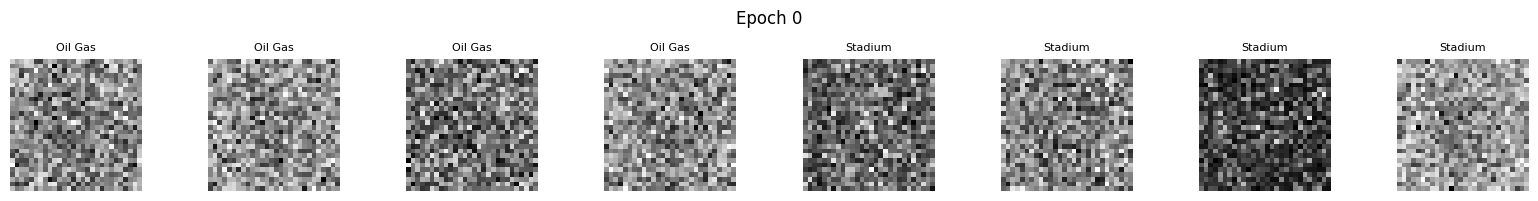

[Modified] Epoch 010/301 | Loss D: -1.5379 | Loss G: -0.5998 | W-dist: 1.6921


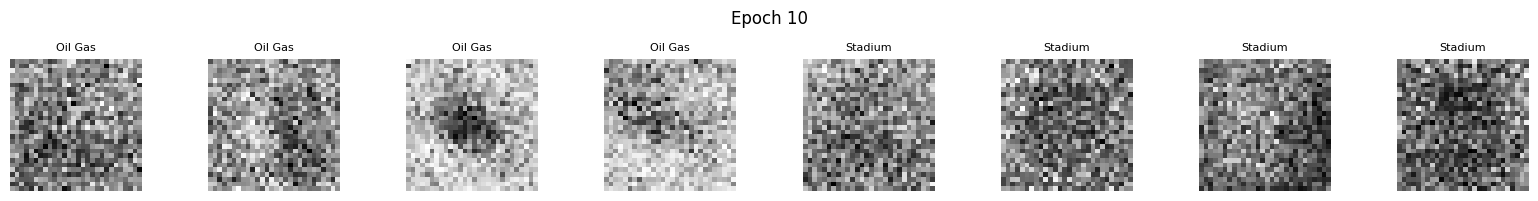

[Modified] Epoch 020/301 | Loss D: -0.2981 | Loss G: -3.1190 | W-dist: 0.3820


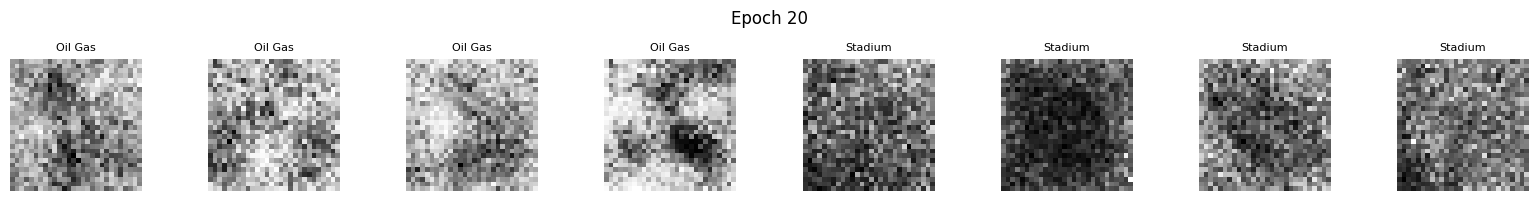

[Modified] Epoch 030/301 | Loss D: -1.3196 | Loss G: -1.2565 | W-dist: 1.5226


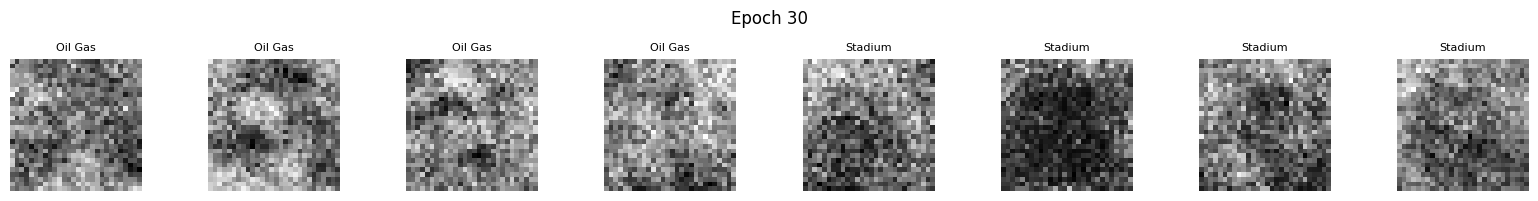

[Modified] Epoch 040/301 | Loss D: -0.7229 | Loss G: -1.3485 | W-dist: 0.8075


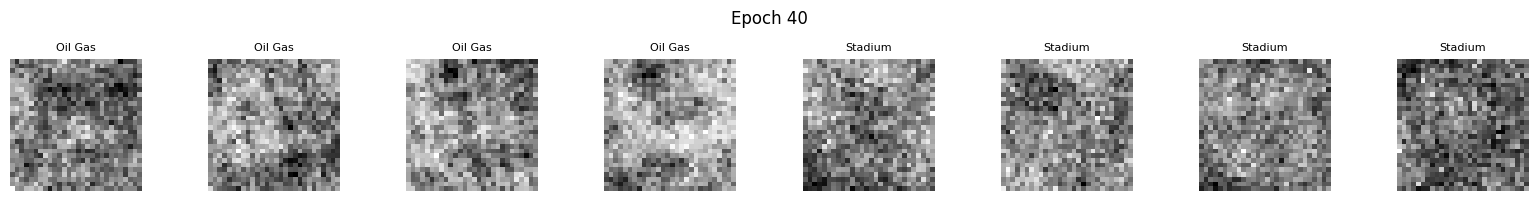

[Modified] Epoch 050/301 | Loss D: -0.4219 | Loss G: -3.8100 | W-dist: 0.5075


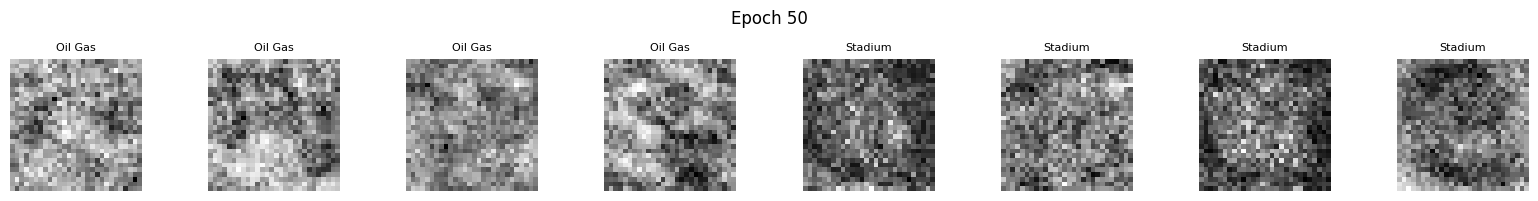

[Modified] Epoch 060/301 | Loss D: -1.1625 | Loss G: 0.1756 | W-dist: 1.2549


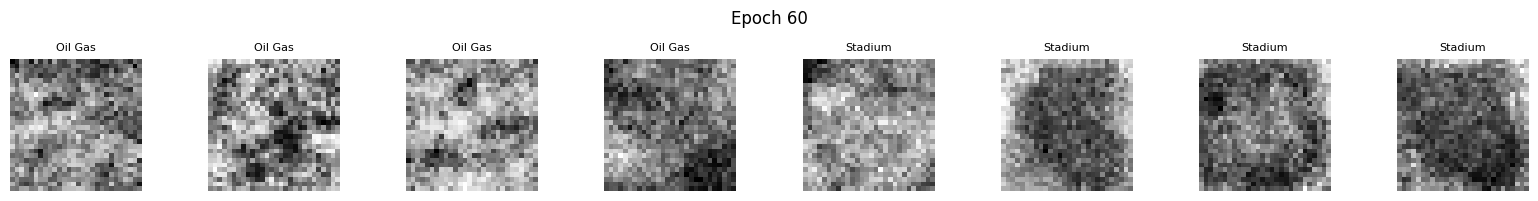

[Modified] Epoch 070/301 | Loss D: -0.4387 | Loss G: -2.0971 | W-dist: 0.5627


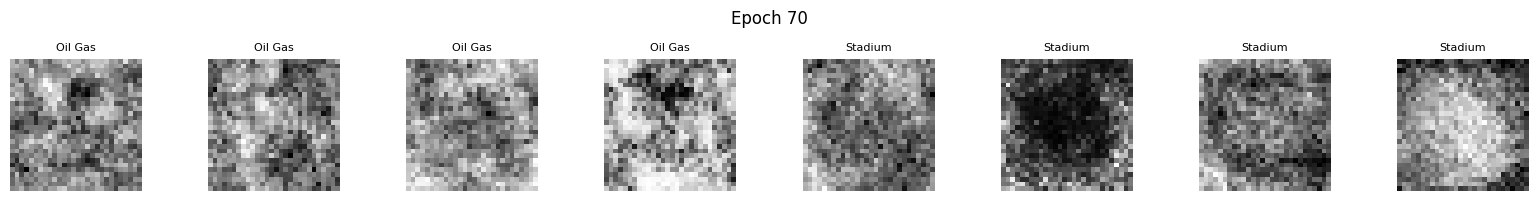

[Modified] Epoch 080/301 | Loss D: -0.9128 | Loss G: -1.7170 | W-dist: 1.0285


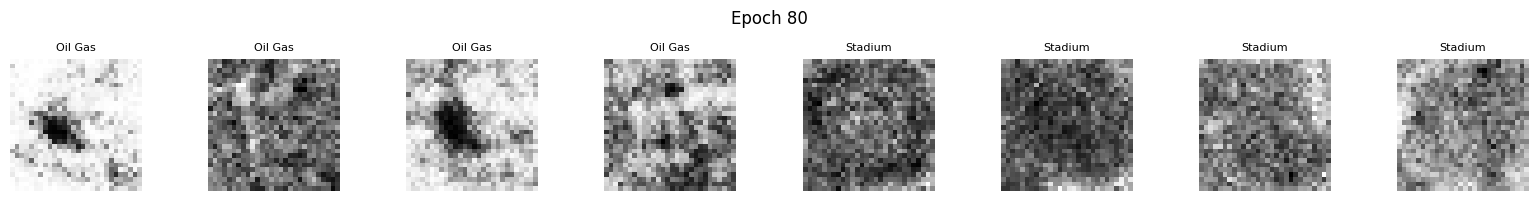

[Modified] Epoch 090/301 | Loss D: -1.4225 | Loss G: -3.1028 | W-dist: 1.5291


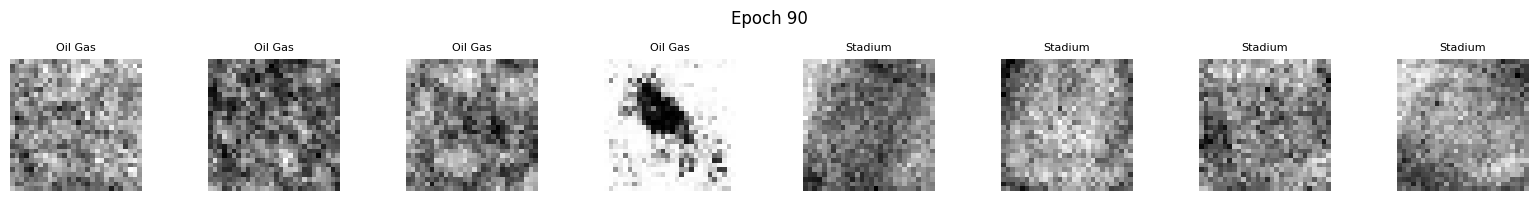

[Modified] Epoch 100/301 | Loss D: -1.8389 | Loss G: -1.2634 | W-dist: 2.0177


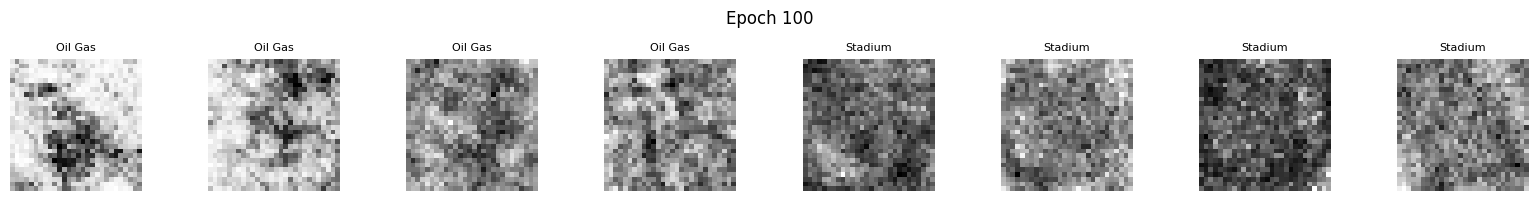

[Modified] Epoch 110/301 | Loss D: -1.2496 | Loss G: -1.3690 | W-dist: 1.4848


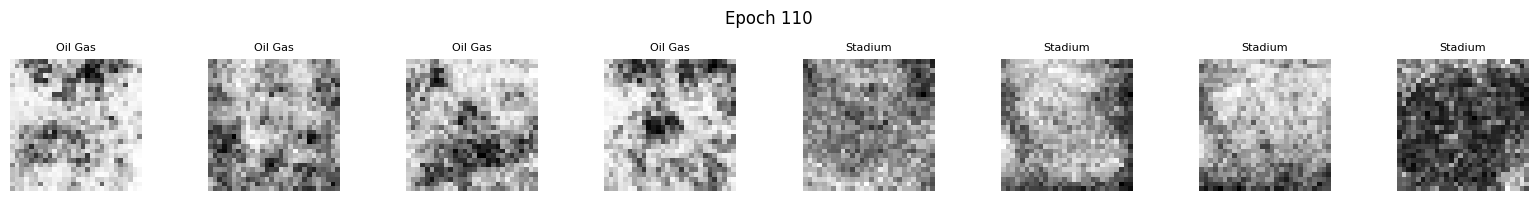

[Modified] Epoch 120/301 | Loss D: -1.2986 | Loss G: -5.4726 | W-dist: 1.4362


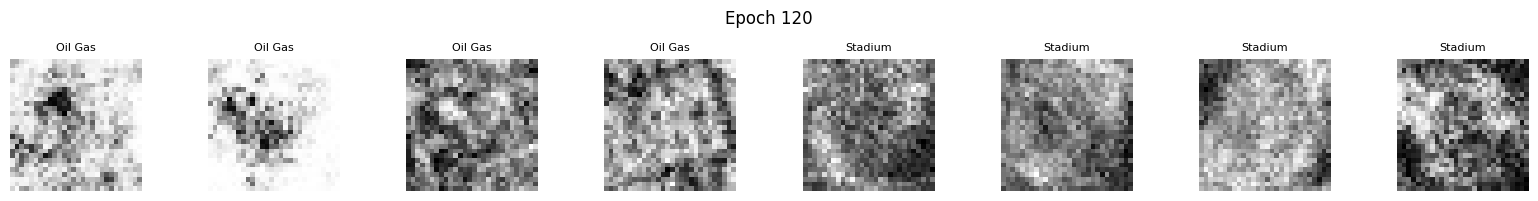

[Modified] Epoch 130/301 | Loss D: -0.8350 | Loss G: -1.4995 | W-dist: 0.9568


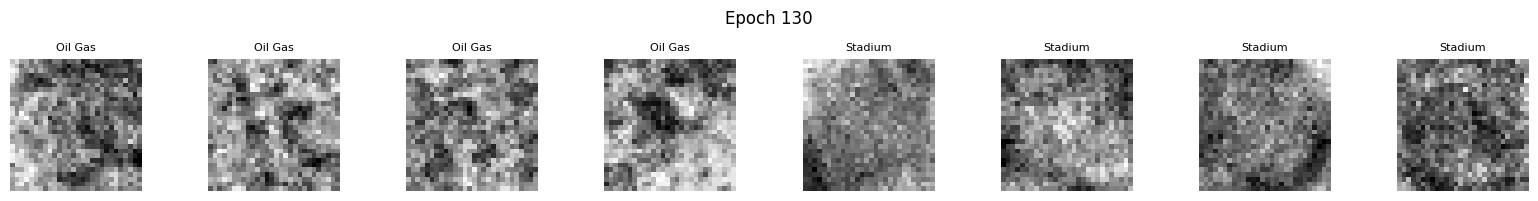

[Modified] Epoch 140/301 | Loss D: -1.5038 | Loss G: -2.0958 | W-dist: 1.6007


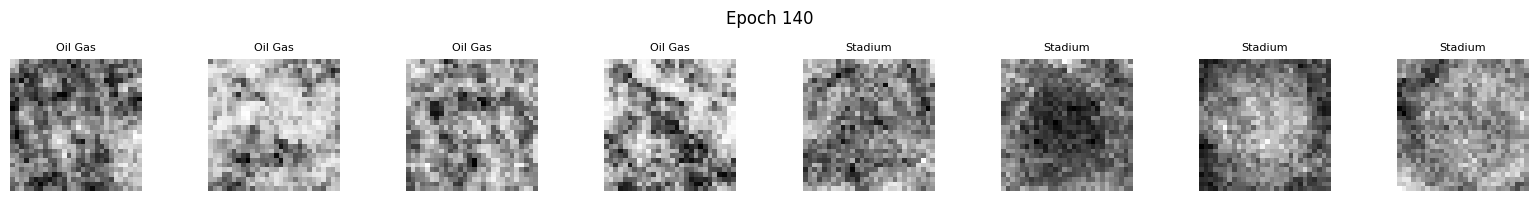

[Modified] Epoch 150/301 | Loss D: -1.5948 | Loss G: -1.3154 | W-dist: 1.7281


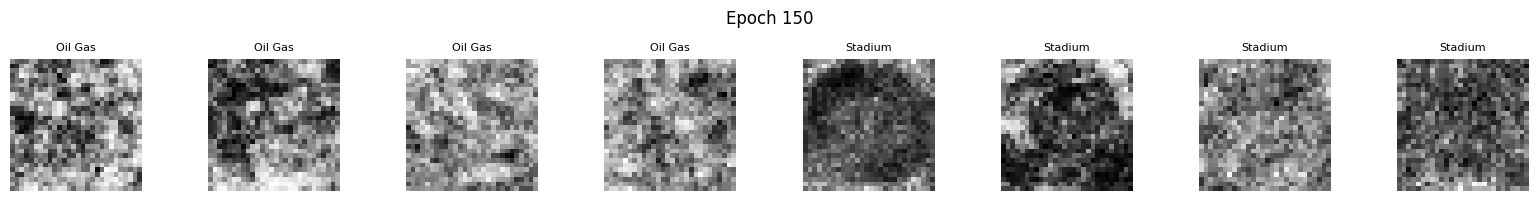

[Modified] Epoch 160/301 | Loss D: 0.2147 | Loss G: -3.0773 | W-dist: -0.1030


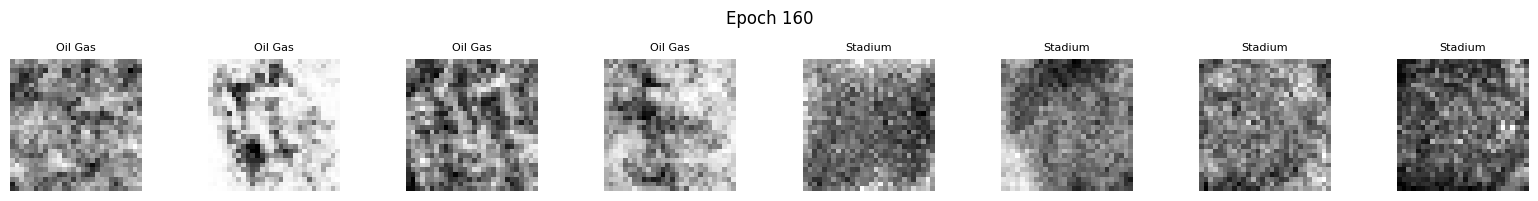

[Modified] Epoch 170/301 | Loss D: -1.0095 | Loss G: -2.6104 | W-dist: 1.2088


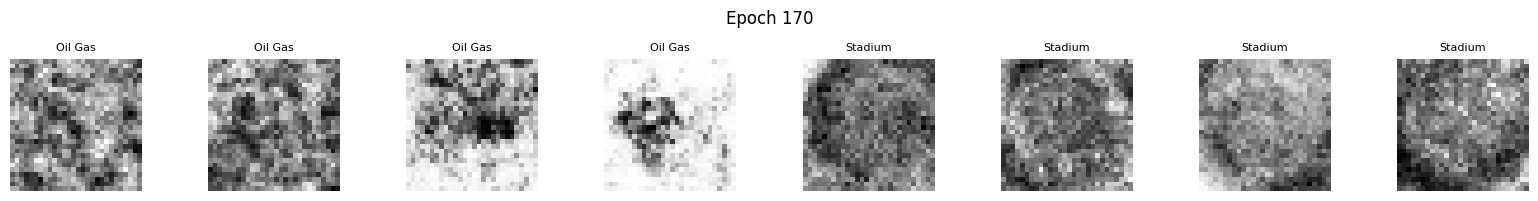

[Modified] Epoch 180/301 | Loss D: -0.7669 | Loss G: -0.6706 | W-dist: 0.9710


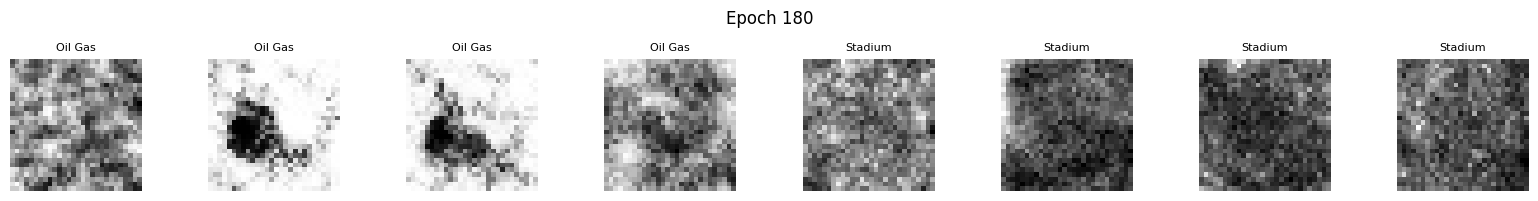

[Modified] Epoch 190/301 | Loss D: -1.4186 | Loss G: -3.7441 | W-dist: 1.6303


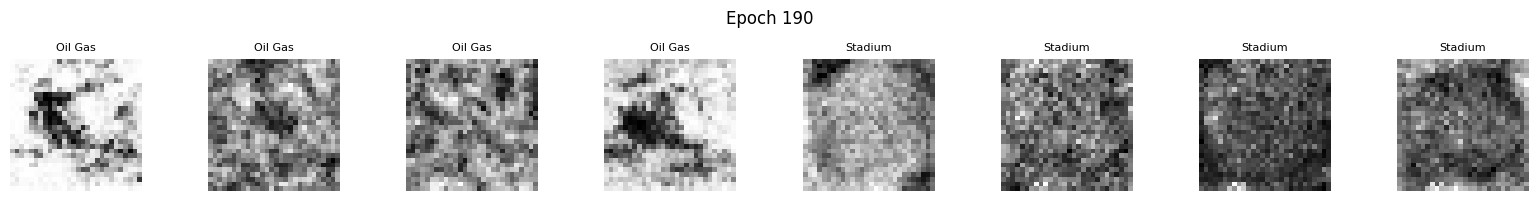

[Modified] Epoch 200/301 | Loss D: -1.4310 | Loss G: -1.2212 | W-dist: 1.5711


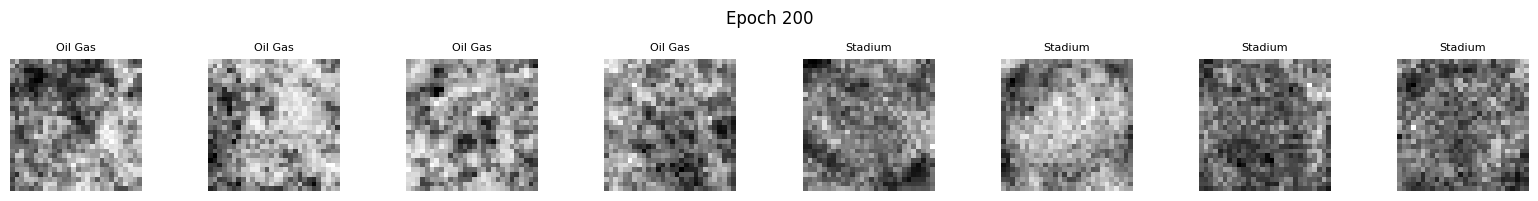

[Modified] Epoch 210/301 | Loss D: -1.5422 | Loss G: 1.7278 | W-dist: 1.7154


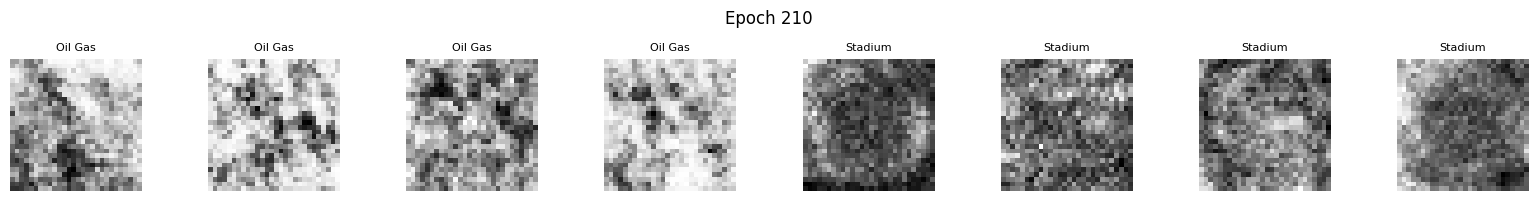

[Modified] Epoch 220/301 | Loss D: -0.9317 | Loss G: 0.2211 | W-dist: 1.0715


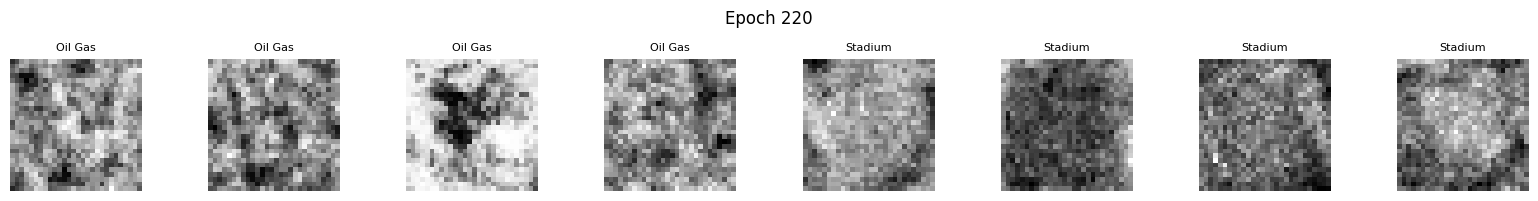

[Modified] Epoch 230/301 | Loss D: -1.0352 | Loss G: -1.3323 | W-dist: 1.2424


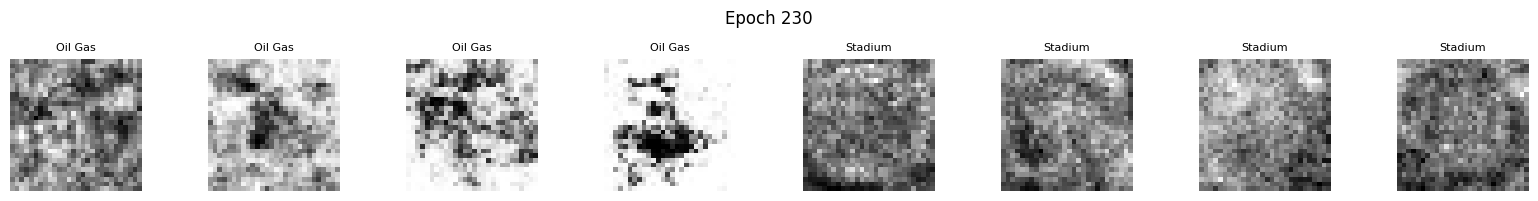

[Modified] Epoch 240/301 | Loss D: -1.4137 | Loss G: -1.5671 | W-dist: 1.5301


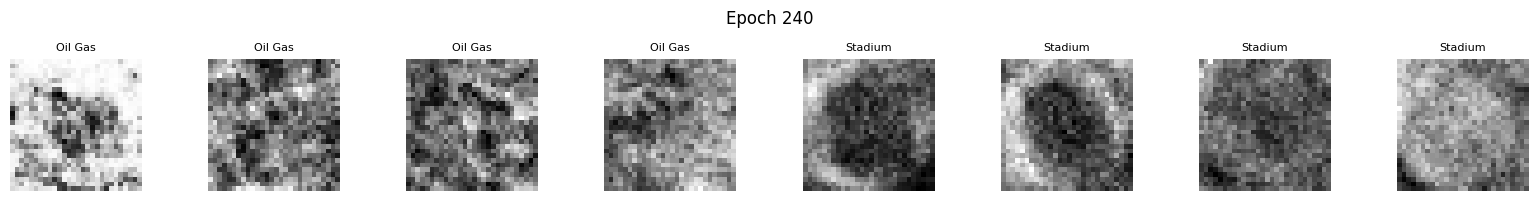

[Modified] Epoch 250/301 | Loss D: -0.8316 | Loss G: -0.4351 | W-dist: 0.9783


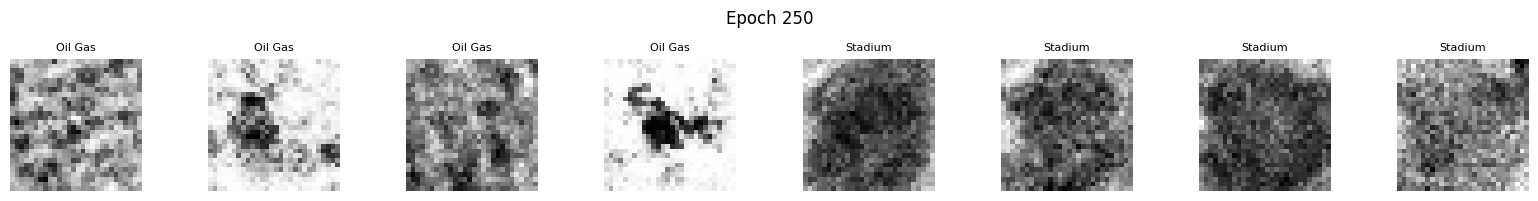

[Modified] Epoch 260/301 | Loss D: -0.5177 | Loss G: -3.0856 | W-dist: 0.6818


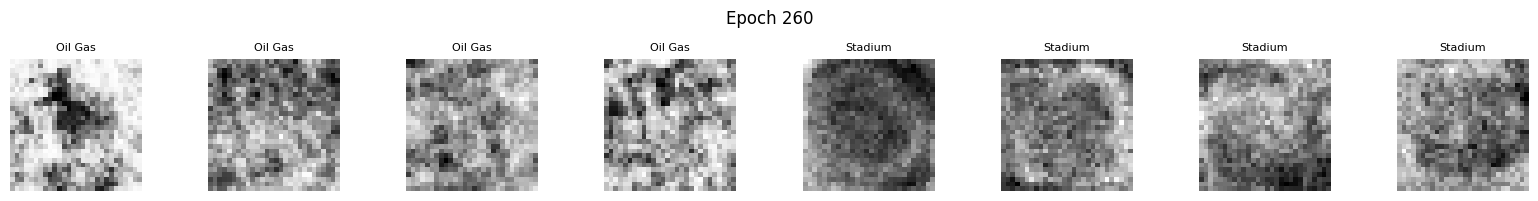

[Modified] Epoch 270/301 | Loss D: -1.0395 | Loss G: 0.7826 | W-dist: 1.1424


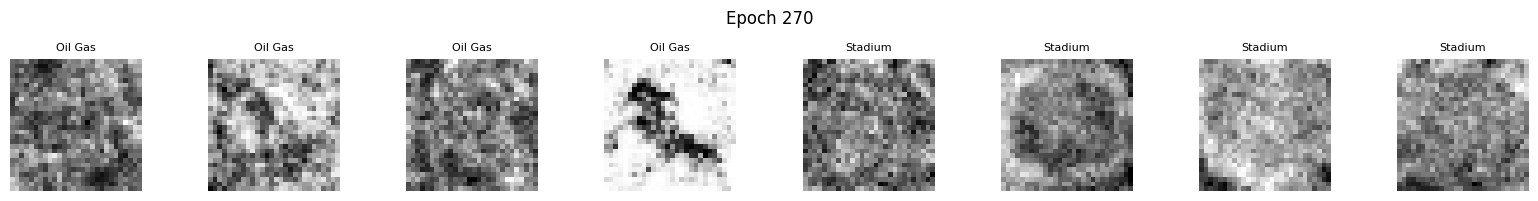

[Modified] Epoch 280/301 | Loss D: -0.6775 | Loss G: -1.5536 | W-dist: 0.8017


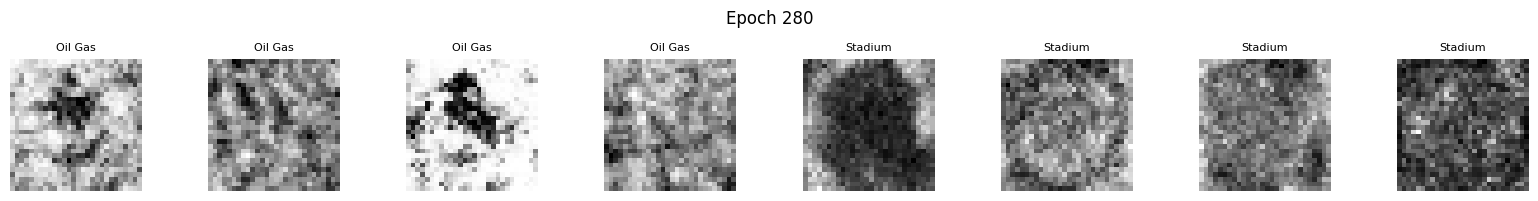

[Modified] Epoch 290/301 | Loss D: -2.0964 | Loss G: -2.7433 | W-dist: 2.3829


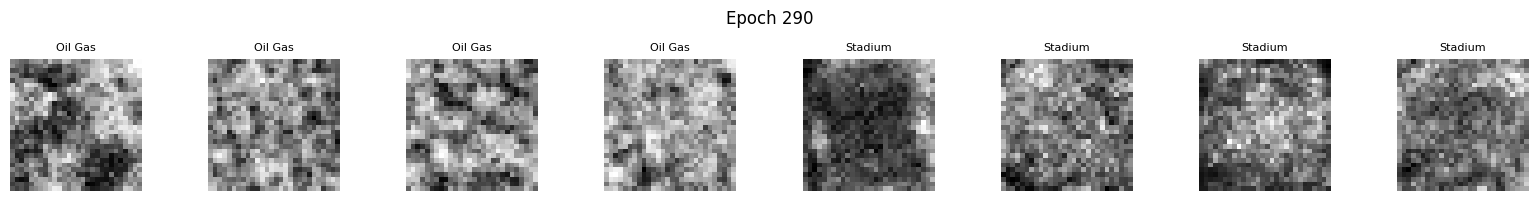

[Modified] Epoch 300/301 | Loss D: -0.9493 | Loss G: -0.5173 | W-dist: 1.1331


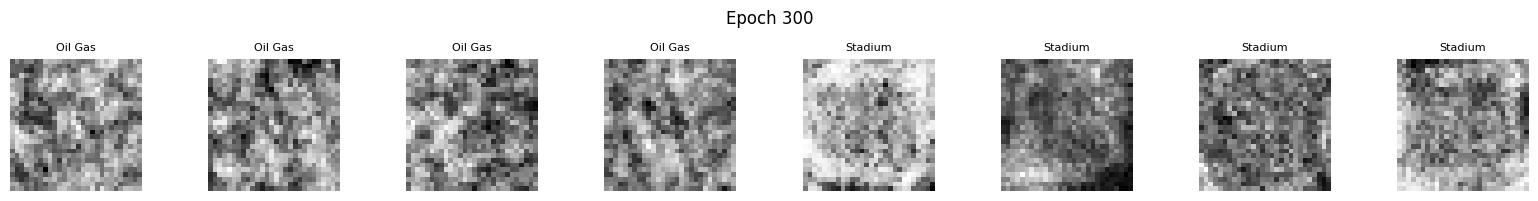

In [17]:
#training GAN
for epoch in range(NUM_EPOCHS + 1):
    gen_m.train()
    disc_m.train()

    for real_imgs, labels in dataloader:
        B = real_imgs.size(0)

        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)

        # Discriminator sebanyak n_critic
        for _ in range(N_CRITIC):
            disc_m.zero_grad()

            z = torch.randn(B, NOISE_DIM, device=device)
            fake_imgs = gen_m(z, labels)

            loss_real = -disc_m(real_imgs, labels).mean()
            loss_fake =  disc_m(fake_imgs.detach(), labels).mean()

            gp = compute_gradient_penalty(disc_m, real_imgs, fake_imgs, labels, device, LAMBDA_GP)
            loss_d = loss_real + loss_fake + gp
            loss_d.backward()
            opt_d_m.step()

        # Generator
        gen_m.zero_grad()

        z = torch.randn(B, NOISE_DIM, device=device)
        fake_imgs = gen_m(z, labels)

        loss_g = -disc_m(fake_imgs, labels).mean()
        loss_g.backward()
        opt_g_m.step()

    if epoch % 10 == 0:
        w_dist = -(loss_real.item() + loss_fake.item())
        print(f"[Modified] Epoch {epoch:03d}/{NUM_EPOCHS} | "
              f"Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f} | "
              f"W-dist: {w_dist:.4f}")

        gen_m.eval()
        with torch.no_grad():
            vis_labels = torch.cat([torch.zeros(4), torch.ones(4)]).long().to(device)
            z_vis      = torch.randn(8, NOISE_DIM, device=device)
            imgs_vis   = gen_m(z_vis, vis_labels).cpu()
            imgs_vis   = (imgs_vis + 1) / 2

        fig, axes = plt.subplots(1, 8, figsize=(16, 2))
        for i in range(8):
            axes[i].imshow(imgs_vis[i].squeeze(), cmap="gray")
            axes[i].set_title("Oil Gas" if vis_labels[i] == 0 else "Stadium", fontsize=8)
            axes[i].axis("off")
        plt.suptitle(f"Epoch {epoch}")
        plt.tight_layout() 
        plt.show()
        gen_m.train()

Hasil training menunjukkan perubahan loss yang berbeda dari baseline. Nilai Loss D dan Loss G yang berfluktuasi di nilai negatif. Artinya,  Critic dan Generator keduanya sedang aktif belajar (dibandingkan dengan  baseline yang stagnan dan hanya random guess). W-dist dipakai sebagai metrik utama konvergensi, terlihat naik-turun di rentang 0.80–2.38 hingga epoch 300. Hal ini berarti model belum menunjukkan tren penurunan yang stabil dan model masih dalam fase belajar aktif dan belum sepenuhnya konvergen. Untuk mengatasi hal ini, direkomendasikan penambahan epoch untuk training hingga konvergensi tercapai.

## FID Comparison

In [18]:
# FID calc
gen_m.eval()
fid_m = FrechetInceptionDistance(feature=2048).to(device)

with torch.no_grad():
    for real_imgs, labels in val_loader:
        B = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)

        z = torch.randn(B, NOISE_DIM, device=device)
        fake_imgs = gen_m(z, labels)

        real_fid = preprocess_for_fid(real_imgs)
        fake_fid = preprocess_for_fid(fake_imgs)

        fid_m.update(real_fid, real=True)
        fid_m.update(fake_fid, real=False)

fid_score_modified = fid_m.compute().item()
print(f"FID Score (Test Set): {fid_score_modified:.4f}")

FID Score (Test Set): 248.2988


In [19]:
print(f"  Baseline FID  : {fid_score_baseline:.4f}")
print(f"  Modified FID  : {fid_score_modified:.4f}")

change = fid_score_baseline - fid_score_modified
print(f"Perubahan: {change:.4f}")

  Baseline FID  : 310.7437
  Modified FID  : 248.2988
Perubahan: 62.4450


Membandingkan skor FID kedua model, modified FID mendapat 248.2988, sedangkan baseline di 310.7437 (turun 62.4450 poin). Hal ini merupakan penurunan yang cukup signifikan dan tercermin secara visual di sampel gambar tiap 10 epoch. Secara visual, pada modified mulai tampak struktur dasar objek pada gambar yang dihasilkan, seperti outline dari penambang gas-oil dan bentuk stadium oval. Namun, memang detail dari gambarnya masih sangat blur dan noisy. Perbaikan ini berarti perubahan pada arsitektur, seperti penggunaan LeakyReLU sebagai activation function, penggantian loss ke Wasserstein dengan Gradient Penalty, hingga penambahan BatchNorm pada Generator dan Dropout pada Discriminator, berhasil membuat Generator dan Discriminator saling belajar.